# Hypothesis 1 And Concept-Copying Analysis (parametric)

Mirror of `result_analysis.ipynb` driven by two knobs in the setup cell:

- `MODEL_NAME` — selects the model whose cache to load (e.g. `"Qwen3-8B"`, `"Olmo-3-1025-7B"`, `"Llama-3.1-8B"`).
- `INDEX_TYPE` — selects which previous-context positions count as the p2 target: `"p2_context"` (all positions where the suffix token appears in the prior block, default) or `"p2_prev"` (the single position immediately before p1). Requires running `improbable_bigram_scores.py --index-type <value>` for that run dir first.
- `WEIGHTED` — flips between *raw* attention scores (`ntm_raw`/`ltm_raw`, sum of attention probabilities) and *value-weighted* scores (`ntm_value_weighted`/`ltm_value_weighted`, attn × value-norm, renormalized). The flag flows through every summary, plot, heatmap, and interpretation markdown downstream.

The notebook loads:

- `cache/improbable_bigrams/{MODEL_NAME}/updated_table1_literal/` — improbable bigrams
- `cache/improbable_bigrams/{MODEL_NAME}/selected_two_token_concepts/` — coherent 2-token concept control
- `cache/improbable_bigrams/{MODEL_NAME}/random_tokens/` — random two-token phrase control
- `cache/causal_scores/{MODEL_NAME}/{concept_copying,token_copying}_len30_n1024.json` — head rankings (Section 2)

To switch settings, edit `MODEL_NAME`, `WEIGHTED`, and/or `INDEX_TYPE` in the setup cell and re-run all cells. Figure save dirs derive from `MODEL_SLUG`; figure filenames pick up `_raw`/`_weighted` suffixes so the variants don't overwrite each other.

In [71]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )
    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import analysis_utils as h1

h1 = importlib.reload(h1)

h1.configure_matplotlib()

# One knob drives the whole notebook. Flip MODEL_NAME and re-run all cells to
# switch between models — figure dirs and cache lookups derive from this.
MODEL_NAME = "Llama-3.1-8B"  # e.g. "Olmo-3-1025-7B"
MODEL_SLUG = MODEL_NAME.lower().replace("-", "_").replace(".", "_")

# Toggle between raw NTM/LTM (sum of attention probabilities) and value-weighted
# NTM/LTM (attn × value-norm, renormalized). Affects every summary, plot, and
# heatmap downstream. Figure filenames pick up a suffix so the two variants
# don't overwrite each other on disk.
WEIGHTED = True
WEIGHTED_TAG = "weighted" if WEIGHTED else "raw"

# Toggle between p2_context (all previous-context positions where the
# suffix token appears) and p2_prev (the single position immediately
# before p1). Runs improbable_bigram_scores.py --index-type <value> first.
INDEX_TYPE = "p2_prev"  # or "p2_prev"

CACHE = h1.load_cache(ROOT, model_name=MODEL_NAME, index_type=INDEX_TYPE)
DEFAULT_TOP_K = 32
ROOT

PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction')

## Shared Cache Checks

Verify that the traced cache and both control caches are available before either analysis section.

In [72]:
display(Markdown(h1.trace_consistency_markdown(CACHE)))
overview = h1.dataset_overview(CACHE)
display(overview)

### Trace Consistency
The prompt-summary JSON is not present in this repo snapshot. The notebook therefore uses the traced cache directly.

,dataset,examples,hallucinated_second_token,copied
0,Improbable summary,100,34,66
1,Updated trace cache,100,34,66
2,2-token concept cache,36,0,36
3,Random phrase cache,35,0,35


# Hypothesis 1 Analysis

Token-induction diagnostics for Qwen3-8B on the improbable-bigram repetition setup:

- token induction heads should keep attending to the desired earlier suffix token, measured with `NTM`
- token induction heads should keep contributing to the correct second-token prediction, measured with `DLA`

Improbable trace lives in `updated_table1_literal/`; controls in `selected_two_token_concepts/` and `random_tokens/`.

In [73]:
summary = h1.build_pairwise_summary(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)
display(summary.round(6))
display(Markdown(h1.interpretation_markdown(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Token NTM (value-weighted),Hallucinated - Copied,0.031493,0.029814,0.001679,-0.000613,0.003994
1,Token NTM (value-weighted),Hallucinated - 2-token concepts,0.031493,0.049439,-0.017946,-0.021440,-0.014633
2,Token NTM (value-weighted),Hallucinated - Random,0.031493,0.051159,-0.019666,-0.022941,-0.016503
3,Token correct-token DLA,Hallucinated - Copied,0.029569,0.032569,-0.003000,-0.010059,0.003753
4,Token correct-token DLA,Hallucinated - 2-token concepts,0.029569,0.041691,-0.012122,-0.023053,-0.001455
5,Token correct-token DLA,Hallucinated - Random,0.029569,0.073341,-0.043772,-0.054996,-0.033278
6,Hallucinated token DLA,Wrong-token - Correct-token,0.001121,0.029569,-0.028448,-0.036075,-0.020549


### Hypothesis 1 Readout at Top-32
- Hallucinated vs copied NTM: `0.0017` (95% CI `-0.0006` to `0.0040`)
- Hallucinated vs copied correct-token DLA: `-0.0030` (95% CI `-0.0101` to `0.0038`)
- Hallucinated vs 2-token concepts NTM: `-0.0179` (95% CI `-0.0214` to `-0.0146`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.0121` (95% CI `-0.0231` to `-0.0015`)
- Hallucinated vs random NTM: `-0.0197` (95% CI `-0.0229` to `-0.0165`)
- Hallucinated vs random correct-token DLA: `-0.0438` (95% CI `-0.0550` to `-0.0333`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0284` (95% CI `-0.0361` to `-0.0205`)

Within the improbable-bigram set, the traced cache does not show a clear hallucination-specific token-head breakdown. The stronger claim that token-head behavior is similar across all conditions is harder to defend, because the 2-token concept and random-phrase controls are both stronger on the token-head metrics.

,metric,condition,k,mean,ci_low,ci_high
0,Token NTM (value-weighted),Hallucinated improbable,8,0.058466,0.053020,0.064118
1,Token NTM (value-weighted),Copied improbable,8,0.051680,0.048155,0.055037
2,Token NTM (value-weighted),2-token concepts,8,0.068484,0.063002,0.074338
3,Token NTM (value-weighted),Random phrases,8,0.089613,0.082717,0.096718
4,Token NTM (value-weighted),Hallucinated improbable,16,0.039630,0.036476,0.042895
5,Token NTM (value-weighted),Copied improbable,16,0.036141,0.033818,0.038437
6,Token NTM (value-weighted),2-token concepts,16,0.066167,0.061710,0.070646
7,Token NTM (value-weighted),Random phrases,16,0.065237,0.060320,0.070248
8,Token NTM (value-weighted),Hallucinated improbable,32,0.031493,0.029565,0.033436
9,Token NTM (value-weighted),Copied improbable,32,0.029814,0.028467,0.031173


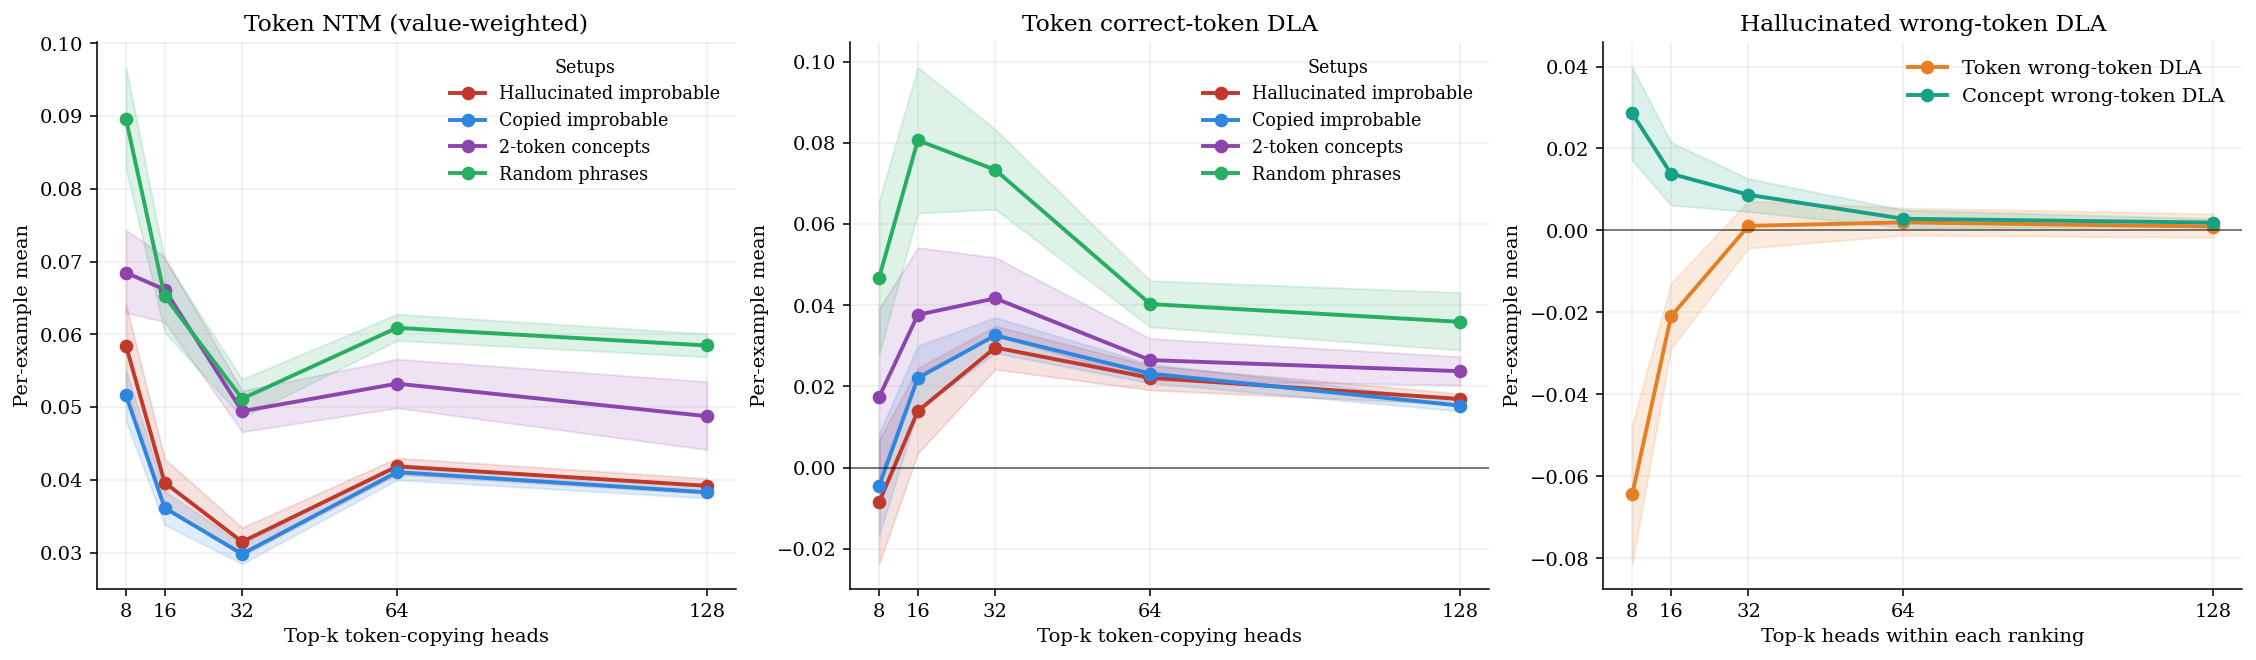

In [74]:
fig, axes, sweep = h1.plot_k_sweep(CACHE, ks=(8, 16, 32, 64, 128), weighted=WEIGHTED)
display(sweep.round(6))

(<Figure size 1680x784 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 token-head NTM (raw)'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 token-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

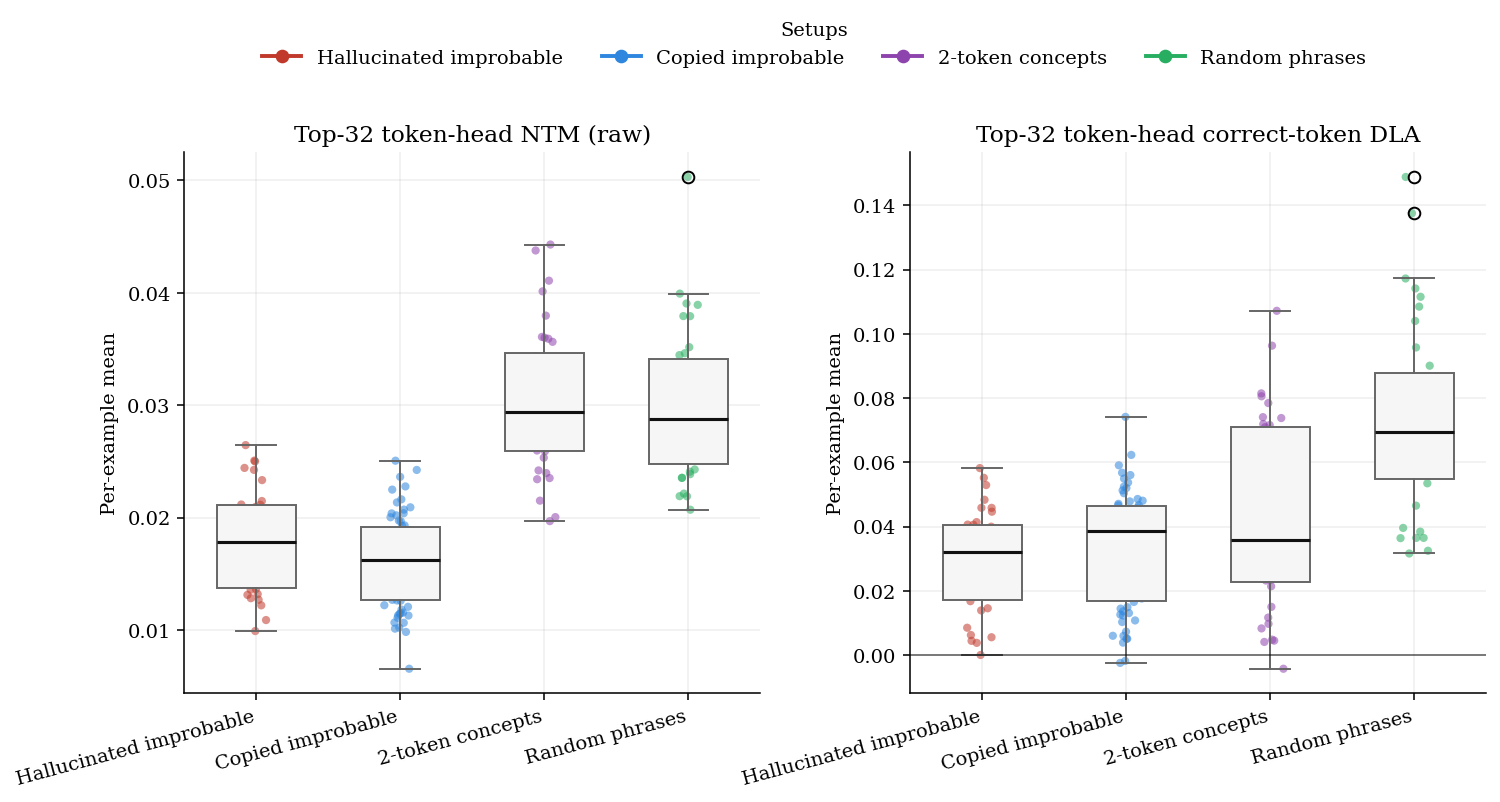

In [70]:
h1.plot_distribution_panels(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 token heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

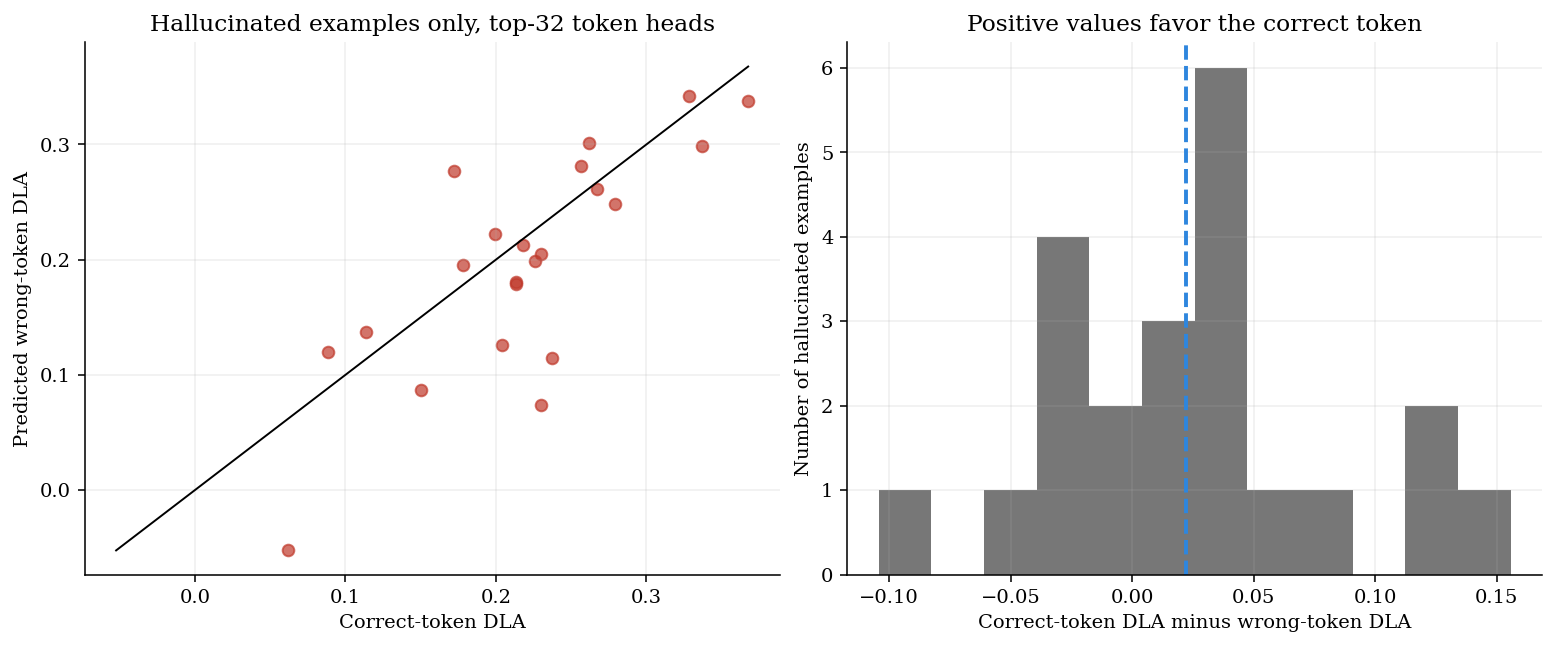

In [41]:
h1.plot_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1890x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 token heads: NTM (value-weighted)'}>,
        <Axes: title={'center': 'Top-16 token heads: DLA'}>], dtype=object))

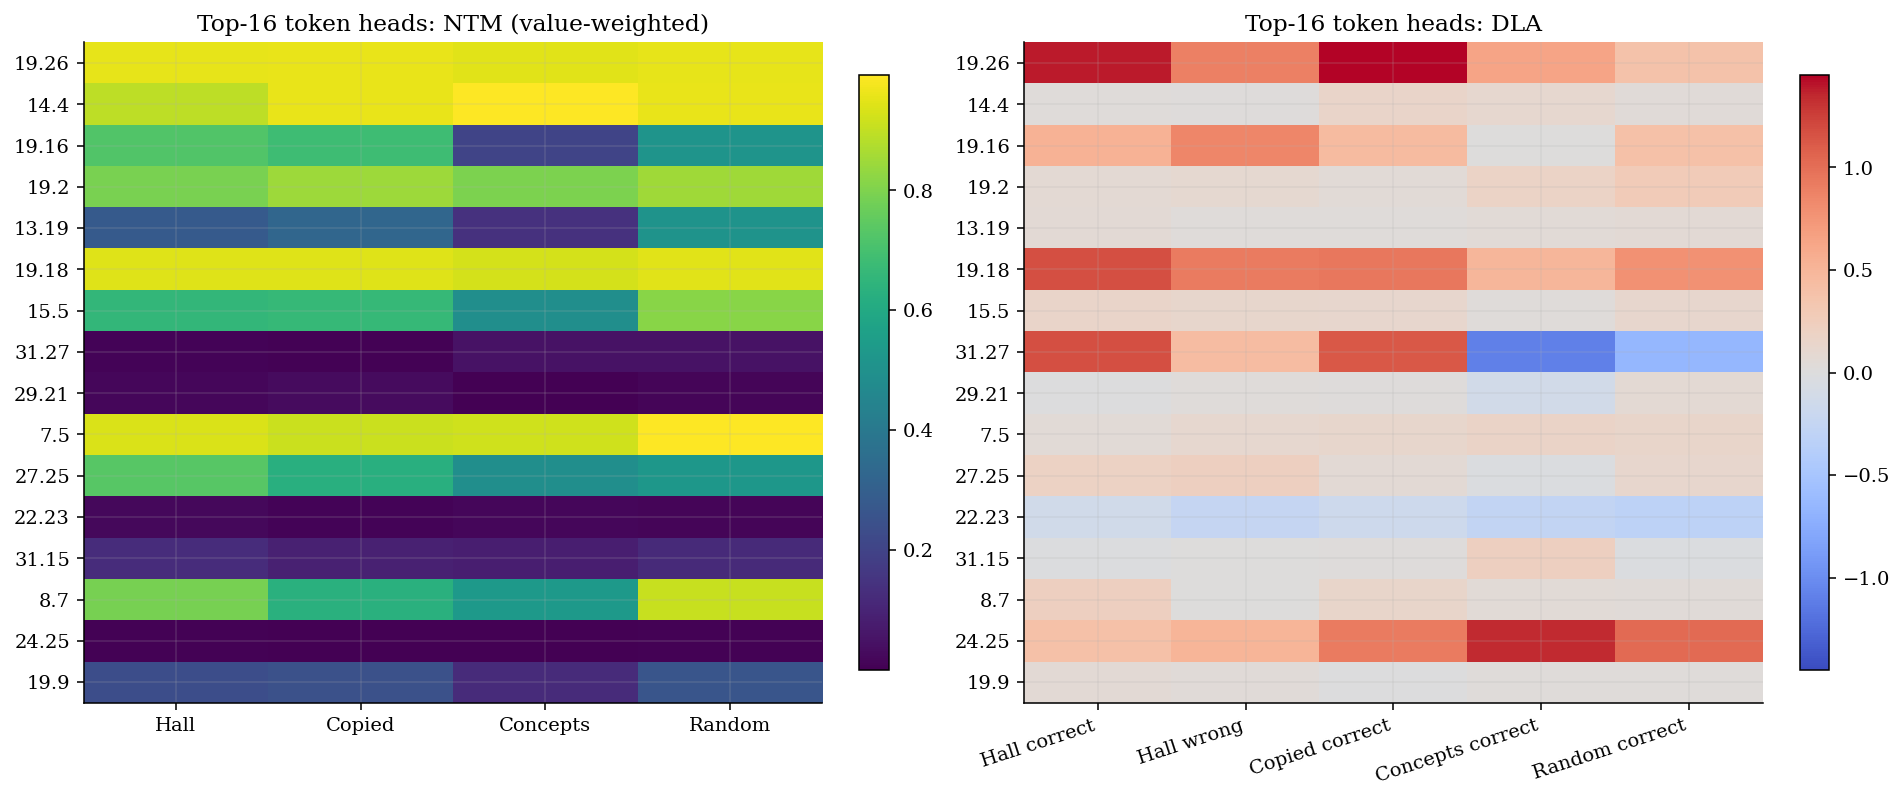

In [42]:
h1.plot_top_head_heatmap(CACHE, top_k=16, weighted=WEIGHTED)

## Are The Highest-DLA Heads Token-Copying Or Concept-Copying?

Rank heads by mean DLA on each example subset and check membership in the token-copying and concept-copying top-K rankings.

In [43]:
TOP_DLA_N = 20
COMPARE_K = 32
SOURCES = [
    "hallucinated_correct",
    "hallucinated_wrong",
    "copied_correct",
    "concepts_correct",
    "random_correct",
]

membership_summary = h1.summarize_top_dla_membership(
    CACHE,
    sources=SOURCES,
    top_n=TOP_DLA_N,
    compare_k=COMPARE_K,
)
display(membership_summary)

for source in SOURCES:
    table = h1.top_dla_membership_table(
        CACHE,
        source=source,
        top_n=TOP_DLA_N,
        compare_k=COMPARE_K,
    )
    display(Markdown(f"### {table['source'].iloc[0]}"))
    display(
        table[
            [
                "head",
                "mean_dla",
                "membership_label",
                "in_token_top_k",
                "in_concept_top_k",
                "token_rank",
                "concept_rank",
            ]
        ].round({"mean_dla": 6})
    )

,source,top_n,compare_k,token_overlap,concept_overlap,both_overlap,neither_overlap,mean_token_rank,mean_concept_rank
0,Hallucinated correct-token DLA,20,32,7,0,0,13,288.30,642.95
1,Hallucinated wrong-token DLA,20,32,8,0,0,12,204.10,586.40
2,Copied-improbable correct-token DLA,20,32,6,0,0,14,279.85,529.25
3,2-token-concept correct-token DLA,20,32,5,1,0,14,380.80,640.70
4,Random-phrase correct-token DLA,20,32,3,0,0,17,341.15,620.40


### Hallucinated correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,23.7,2.736209,Neither,False,False,159,87
1,25.23,2.011138,Neither,False,False,376,897
2,19.26,1.384751,Token only,True,False,1,1004
3,24.1,1.183318,Neither,False,False,739,303
4,31.27,1.170625,Token only,True,False,8,505
5,19.18,1.165685,Token only,True,False,6,188
6,29.26,0.812613,Neither,False,False,962,578
7,28.1,0.729759,Neither,False,False,244,83
8,31.2,0.601665,Neither,False,False,45,511
9,30.0,0.570814,Token only,True,False,21,990


### Hallucinated wrong-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,24.24,2.509909,Neither,False,False,209,858
1,23.7,1.836557,Neither,False,False,159,87
2,24.1,1.753503,Neither,False,False,739,303
3,25.23,1.477447,Neither,False,False,376,897
4,28.1,1.070054,Neither,False,False,244,83
5,29.0,0.977121,Neither,False,False,174,526
6,21.30,0.936461,Neither,False,False,502,727
7,19.18,0.925534,Token only,True,False,6,188
8,19.26,0.884193,Token only,True,False,1,1004
9,19.16,0.855094,Token only,True,False,3,835


...

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,23.7,2.764390,Neither,False,False,159,87
1,24.1,2.426838,Neither,False,False,739,303
2,28.24,1.961469,Neither,False,False,485,103
3,25.23,1.694255,Neither,False,False,376,897
4,26.0,1.599800,Neither,False,False,72,126
5,19.26,1.448407,Token only,True,False,1,1004
6,31.27,1.120789,Token only,True,False,8,505
7,23.12,0.971775,Neither,False,False,176,65
8,19.18,0.949959,Token only,True,False,6,188
9,24.25,0.917162,Token only,True,False,15,432


### 2-token-concept correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,29.26,3.347669,Neither,False,False,962,578
1,19.24,2.691633,Neither,False,False,38,857
2,23.7,1.922219,Neither,False,False,159,87
3,25.23,1.587775,Neither,False,False,376,897
4,30.24,1.486493,Neither,False,False,58,980
5,24.25,1.345063,Token only,True,False,15,432
6,25.3,0.885304,Concept only,False,True,619,25
7,27.19,0.796789,Neither,False,False,543,918
8,24.11,0.740374,Neither,False,False,644,446
9,30.9,0.726871,Neither,False,False,944,987


### Random-phrase correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,30.9,2.417776,Neither,False,False,944,987
1,23.7,2.306124,Neither,False,False,159,87
2,25.10,1.919621,Neither,False,False,94,783
3,31.0,1.897389,Neither,False,False,436,513
4,24.9,1.801091,Neither,False,False,252,679
5,28.1,1.657106,Neither,False,False,244,83
6,24.16,1.642200,Neither,False,False,903,594
7,24.2,1.636210,Neither,False,False,241,376
8,29.8,1.615524,Token only,True,False,31,910
9,30.0,1.604915,Token only,True,False,21,990


PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction/scripts/olmo_3_1025_7b_hypothesis1_figures')

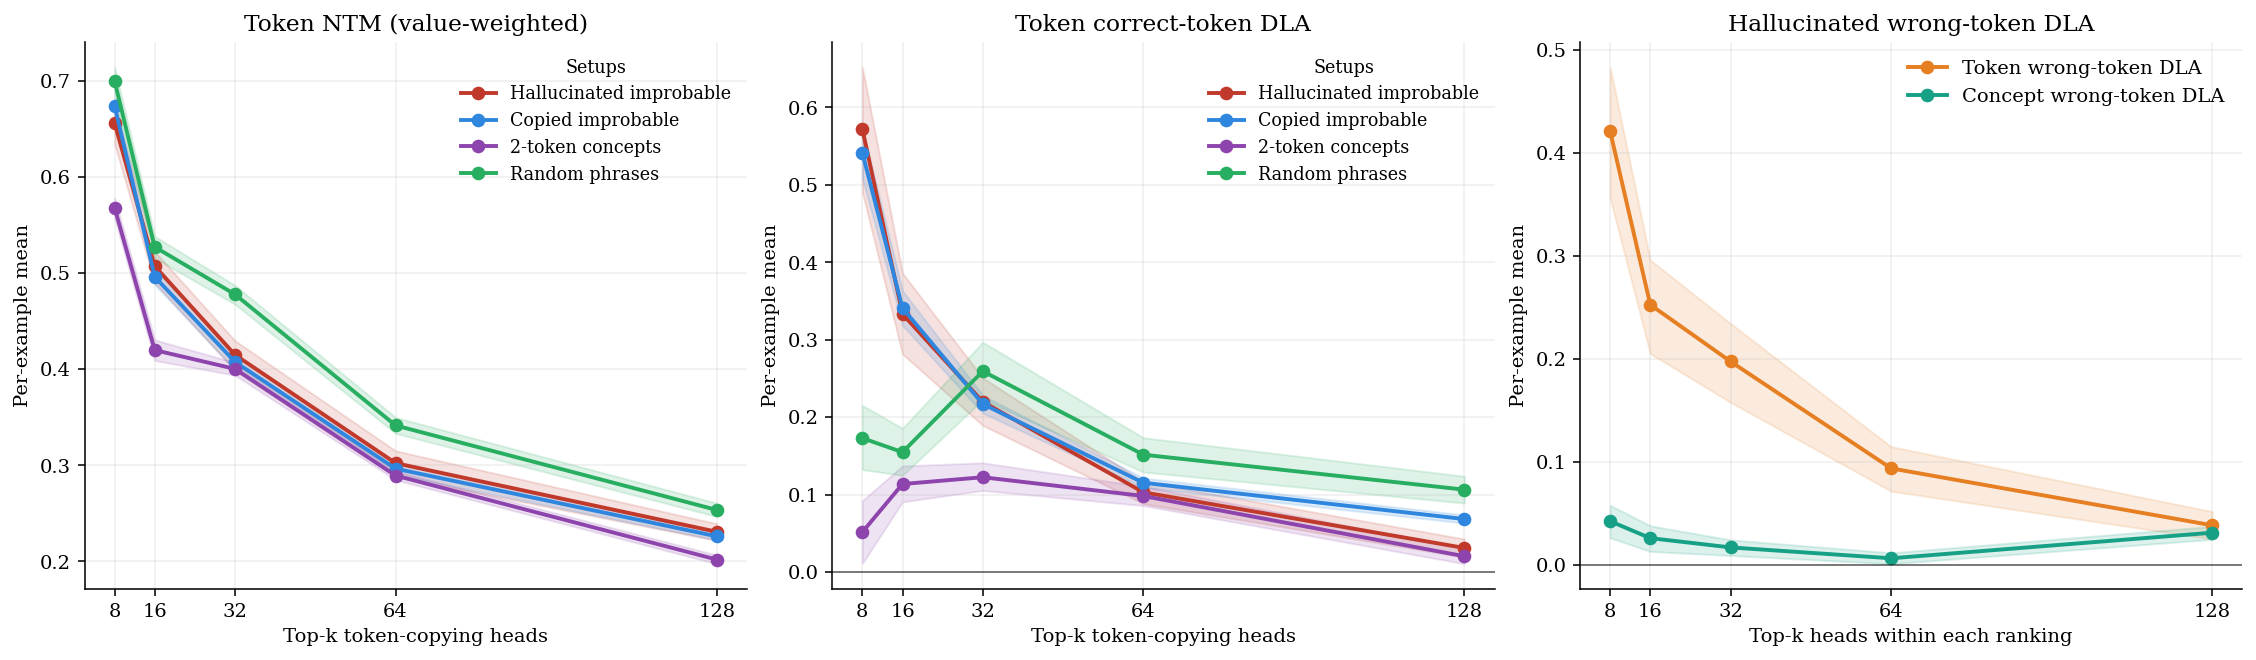

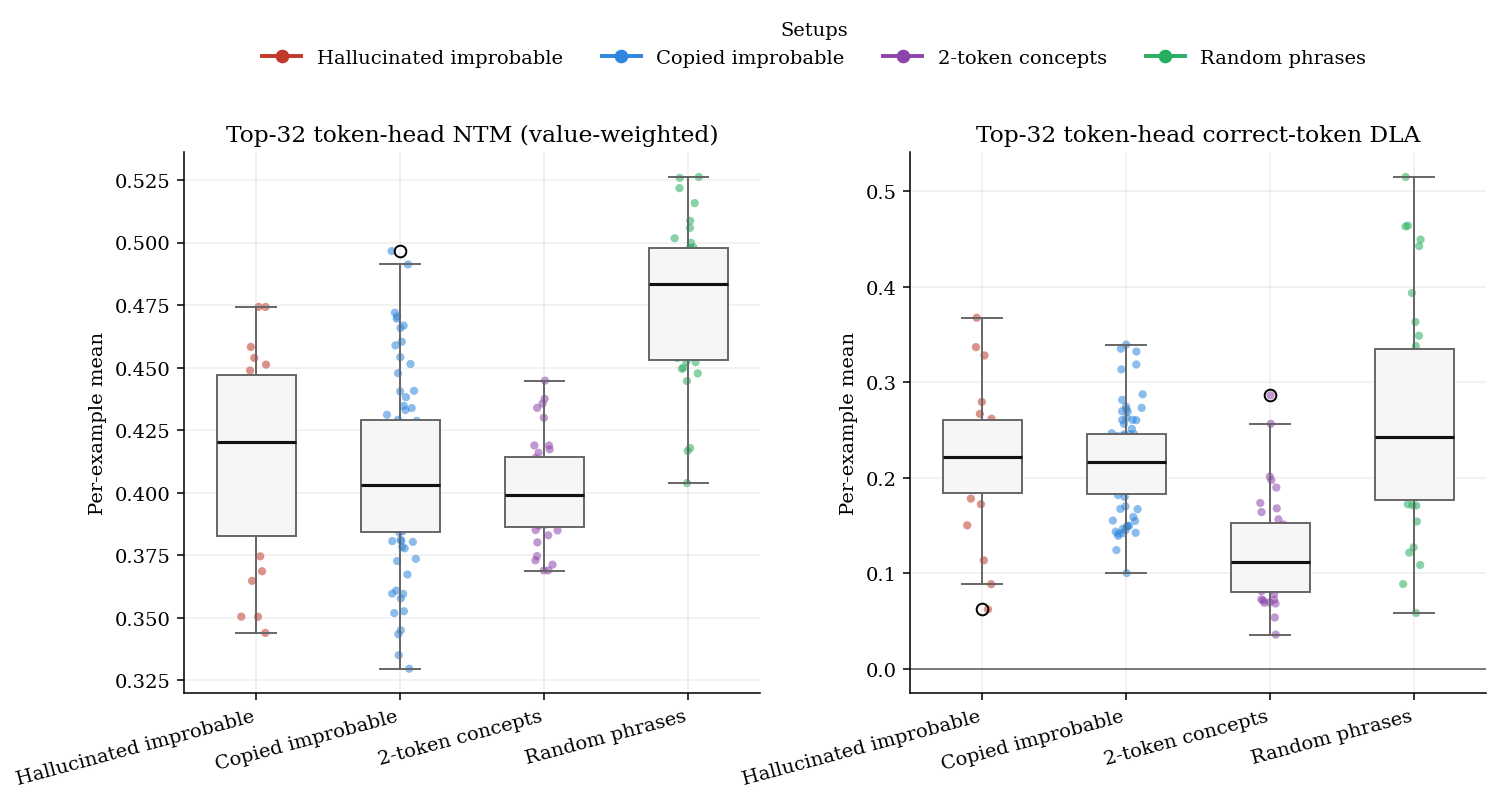

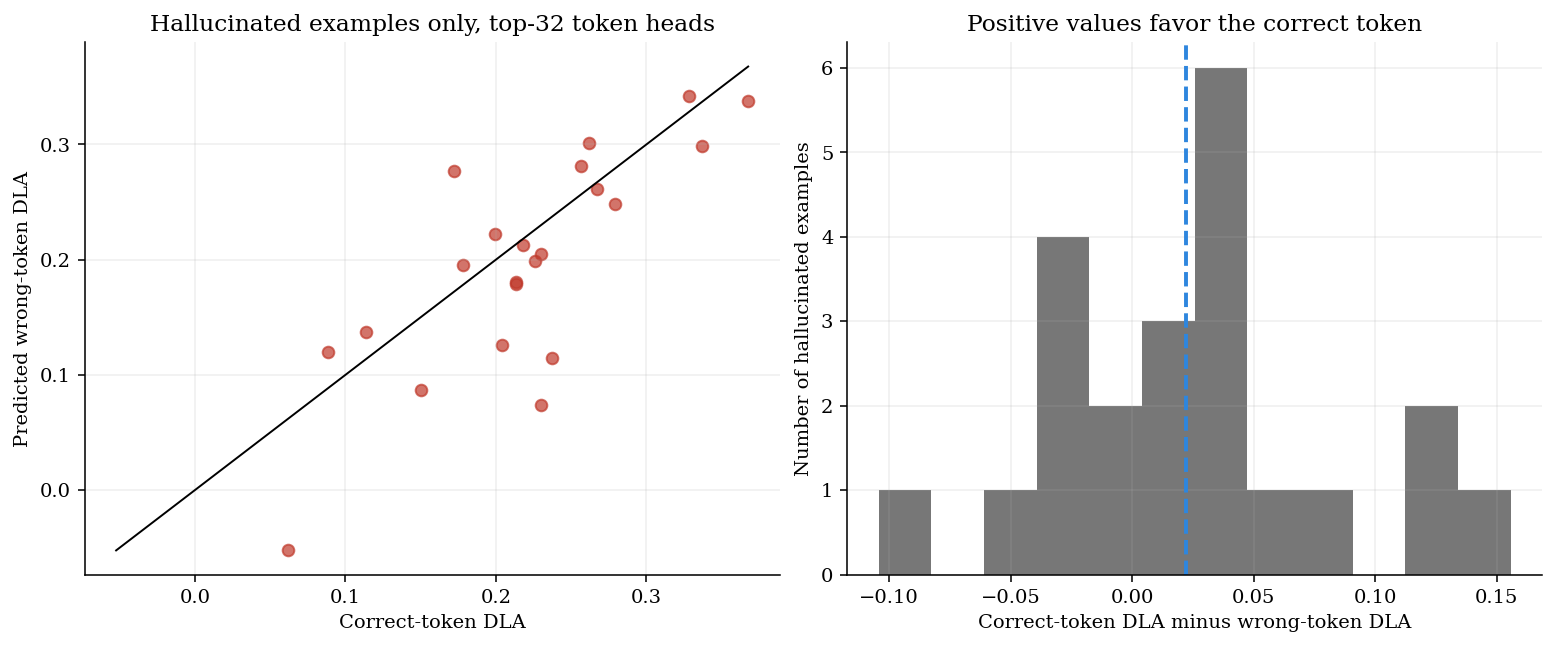

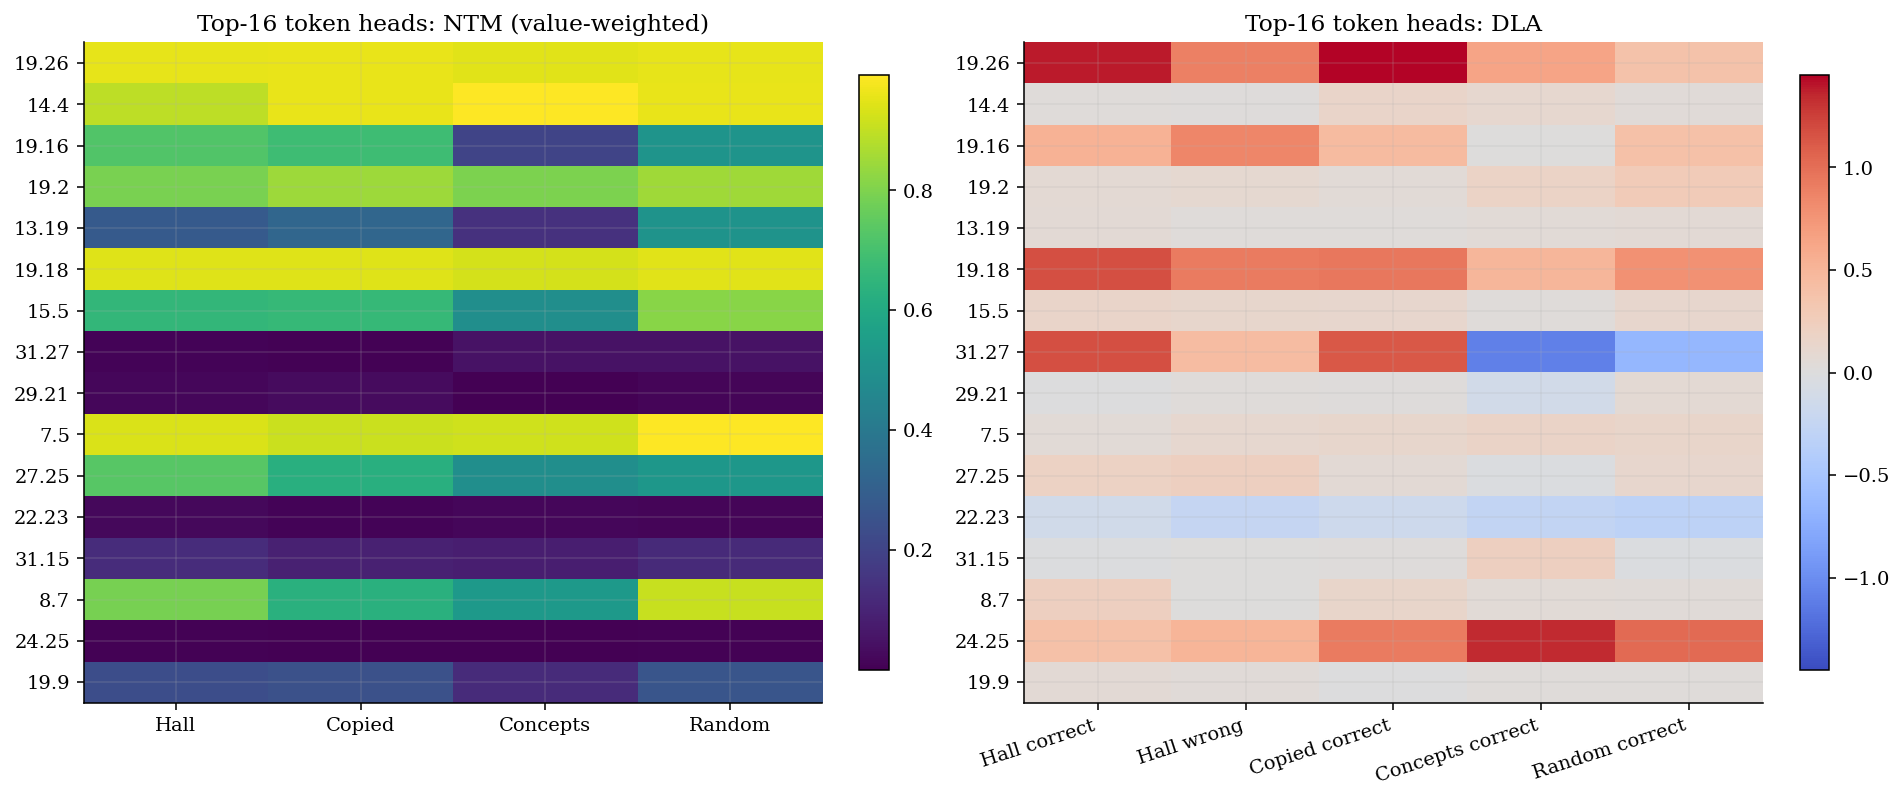

In [44]:
SAVE_DIR = ROOT / "scripts" / f"{MODEL_SLUG}_hypothesis1_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_k_sweep(
    CACHE,
    ks=(8, 16, 32, 64, 128),
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_k_sweep_{WEIGHTED_TAG}.png",
)
_ = h1.plot_distribution_panels(
    CACHE,
    DEFAULT_TOP_K,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_distributions_{WEIGHTED_TAG}.png",
)
_ = h1.plot_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_hallucinated_dla_pair.png"
)
_ = h1.plot_top_head_heatmap(
    CACHE,
    top_k=16,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_top_token_heads_{WEIGHTED_TAG}.png",
)
SAVE_DIR

---

# Concept-Copying Head Analysis

Mirrors `concept_copying_analysis.ipynb`. Reuses the same loaded cache and helper module.

## Coverage

Three conditions are present in the cache:

1. hallucinated improbable bigrams
2. random two-token phrases
3. coherent two-token concepts

Copied improbable examples serve as an additional internal control.

In [52]:
summary = h1.build_concept_pairwise_summary(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)
display(summary.round(6))
display(Markdown(h1.concept_interpretation_markdown(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Concept LTM (value-weighted),Hallucinated - Copied,0.213938,0.205153,0.008784,0.001296,0.015830
1,Concept LTM (value-weighted),Hallucinated - 2-token concepts,0.213938,0.207690,0.006248,-0.001138,0.013815
2,Concept LTM (value-weighted),Hallucinated - Random,0.213938,0.217589,-0.003651,-0.011747,0.004532
3,Concept correct-token DLA,Hallucinated - Copied,0.000351,0.000833,-0.000482,-0.001657,0.000643
4,Concept correct-token DLA,Hallucinated - 2-token concepts,0.000351,-0.000006,0.000356,-0.000849,0.001532
5,Concept correct-token DLA,Hallucinated - Random,0.000351,0.000488,-0.000137,-0.001388,0.001034
6,Hallucinated concept DLA,Wrong-token - Correct-token,0.000186,0.000351,-0.000164,-0.001058,0.000752


### Concept-Head Readout at Top-32
- Hallucinated vs copied LTM: `0.0088` (95% CI `0.0013` to `0.0158`)
- Hallucinated vs copied correct-token DLA: `-0.0005` (95% CI `-0.0017` to `0.0006`)
- Hallucinated vs 2-token concepts LTM: `0.0062` (95% CI `-0.0011` to `0.0138`)
- Hallucinated vs 2-token concepts correct-token DLA: `0.0004` (95% CI `-0.0008` to `0.0015`)
- Hallucinated vs random LTM: `-0.0037` (95% CI `-0.0117` to `0.0045`)
- Hallucinated vs random correct-token DLA: `-0.0001` (95% CI `-0.0014` to `0.0010`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0002` (95% CI `-0.0011` to `0.0008`)

The current cache includes hallucinated improbable bigrams, copied improbable prompts, coherent 2-token concepts, and random two-token phrases. That allows a direct check of whether concept-head behavior on hallucinated prompts looks more like the coherent concept condition or like the random-token control. In the current traced cache, concept heads do not cleanly separate hallucinated prompts from both copied improbable prompts and coherent 2-token concepts, and they do not strongly favor the wrong token over the correct token in hallucinated cases.

,metric,condition,k,mean,ci_low,ci_high
0,Concept LTM (value-weighted),Hallucinated improbable,8,0.320719,0.310067,0.330442
1,Concept LTM (value-weighted),Copied improbable,8,0.317506,0.310632,0.324333
2,Concept LTM (value-weighted),2-token concepts,8,0.346601,0.338850,0.353881
3,Concept LTM (value-weighted),Random phrases,8,0.365780,0.355521,0.376105
4,Concept LTM (value-weighted),Hallucinated improbable,16,0.285426,0.276204,0.294219
5,Concept LTM (value-weighted),Copied improbable,16,0.278580,0.273290,0.283808
6,Concept LTM (value-weighted),2-token concepts,16,0.295694,0.292086,0.299122
7,Concept LTM (value-weighted),Random phrases,16,0.298399,0.291476,0.305202
8,Concept LTM (value-weighted),Hallucinated improbable,32,0.213938,0.206840,0.220707
9,Concept LTM (value-weighted),Copied improbable,32,0.205153,0.202003,0.208448


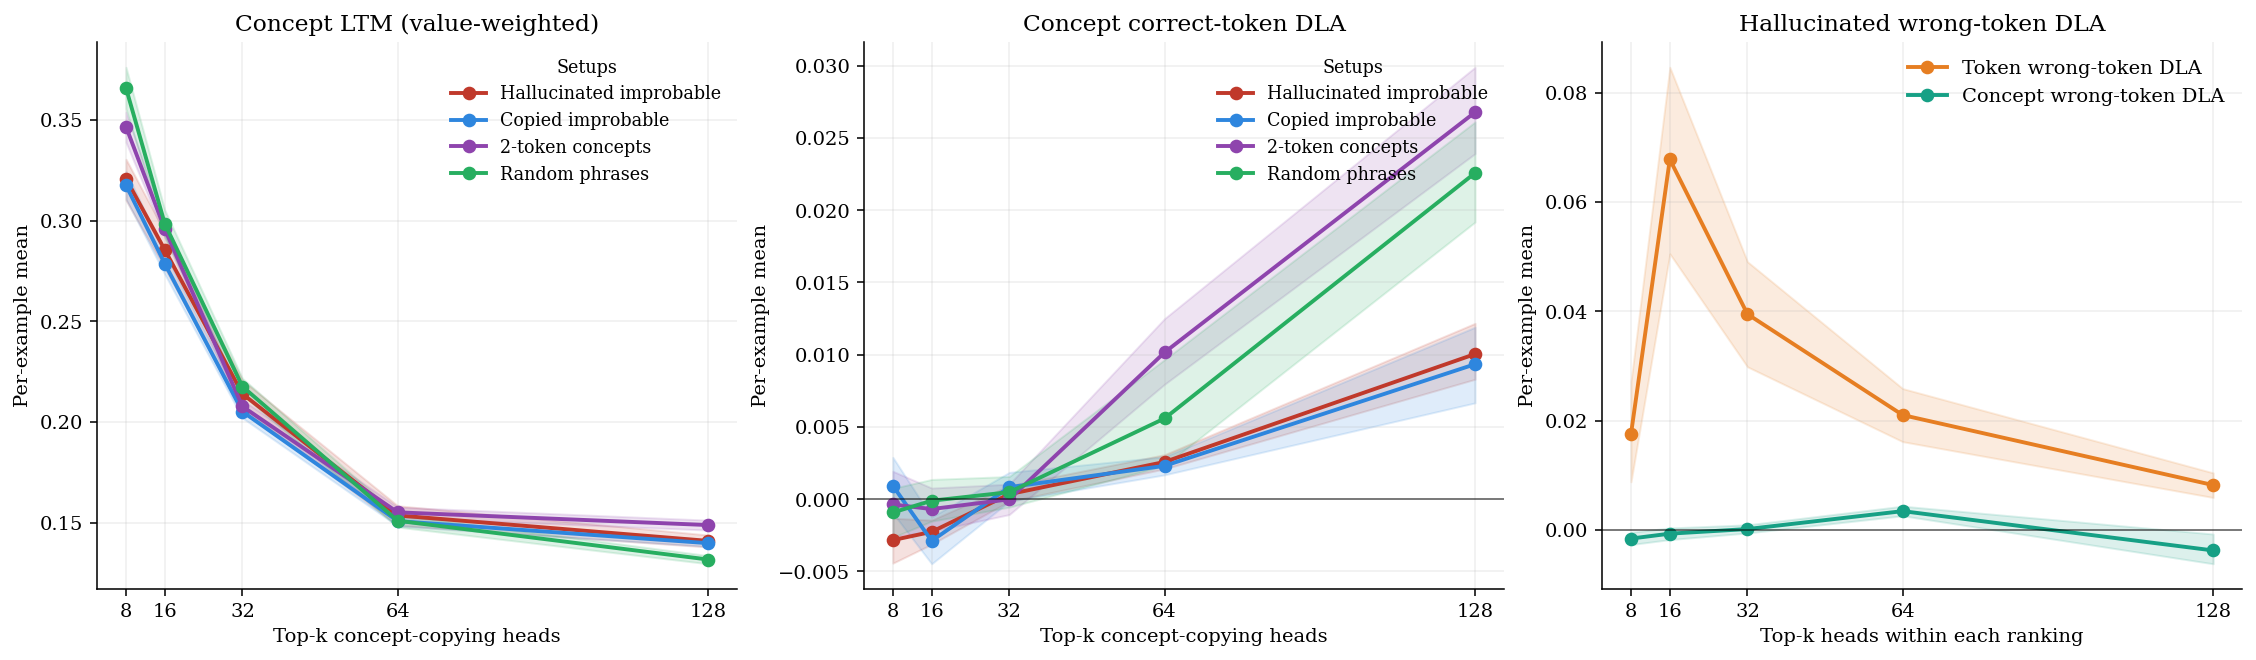

In [53]:
fig, axes, sweep = h1.plot_concept_k_sweep(CACHE, ks=(8, 16, 32, 64, 128), weighted=WEIGHTED)
display(sweep.round(6))

In [ ]:
h1.plot_concept_distribution_panels(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 concept heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

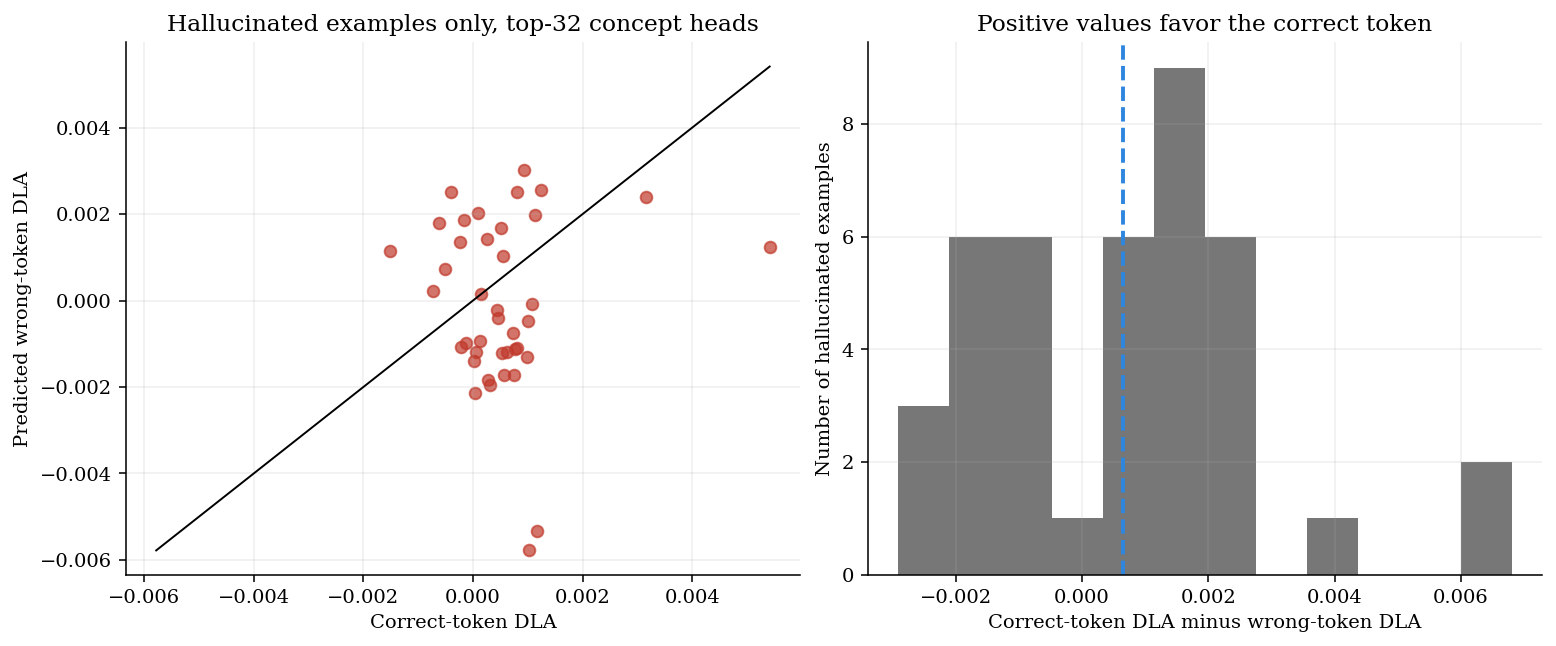

In [13]:
h1.plot_concept_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

In [ ]:
h1.plot_concept_head_heatmap(CACHE, top_k=16, weighted=WEIGHTED)

In [ ]:
SAVE_DIR = ROOT / "scripts" / f"{MODEL_SLUG}_concept_head_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_concept_k_sweep(
    CACHE,
    ks=(8, 16, 32, 64, 128),
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_k_sweep_{WEIGHTED_TAG}.png",
)
_ = h1.plot_concept_distribution_panels(
    CACHE,
    DEFAULT_TOP_K,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_distributions_{WEIGHTED_TAG}.png",
)
_ = h1.plot_concept_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_hallucinated_dla_pair.png"
)
_ = h1.plot_concept_head_heatmap(
    CACHE,
    top_k=16,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_top_heads_{WEIGHTED_TAG}.png",
)
SAVE_DIR